<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Construcci%C3%B3n_de_CNN_Pruebas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. IMPORTACIÓN DE BIBLIOTECAS Y VERIFICACIÓN DE GPU

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Verificamos si Google Colab nos asignó una GPU
print("Versión de TensorFlow:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('Advertencia: No se detectó GPU.')
else:
  print('GPU detectada exitosamente:', device_name)

Versión de TensorFlow: 2.20.0
GPU detectada exitosamente: /device:GPU:0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1760s 10us/step


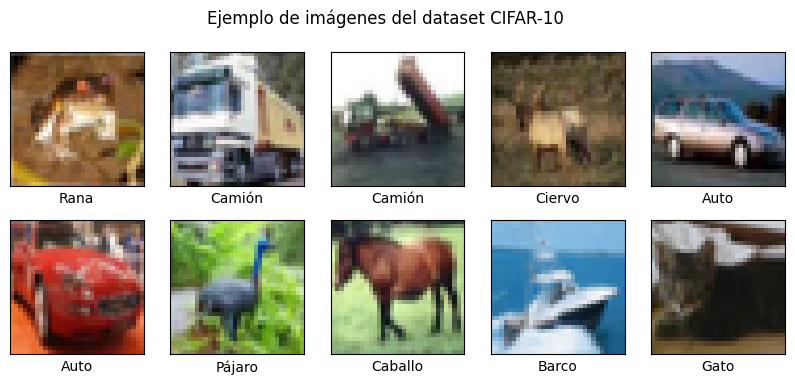

In [2]:
# 2. CARGA Y PREPROCESAMIENTO DE DATOS (CIFAR-10)

# CIFAR-10 contiene imágenes a color (32x32 píxeles, 3 canales RGB)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Nombres de las 10 clases del dataset
class_names = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Ciervo',
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Normalizamos los valores de los píxeles para que estén en el rango [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Visualizamos algunas imágenes de ejemplo
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle("Ejemplo de imágenes del dataset CIFAR-10")
plt.show()

In [3]:
# 3. ARQUITECTURA DE LA RED NEURONAL CONVOLUCIONAL (CNN)

#Explicación de los bloques:
#1. Conv2D: Aplica filtros (detectores de características como bordes, texturas).
#2. MaxPooling2D: Reduce la dimensión espacial (ancho y alto), conservando lo más relevante.
#3. Flatten: Convierte la matriz 2D/3D en un vector 1D.
#4. Dense: Capas totalmente conectadas para clasificar según las características extraídas.

model = models.Sequential([
    # Bloque 1: Extracción de características de bajo nivel (bordes, curvas)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Bloque 2: Extracción de patrones más complejos (texturas, formas)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloque 3: Combinación de patrones avanzados (partes de objetos)
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Clasificador (Red Densa)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # 10 salidas (una por cada clase)
])

# Mostramos el resumen de la arquitectura y la cantidad de parámetros
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 4. COMPILACIÓN Y ENTRENAMIENTO DEL MODELO

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Entrenamos durante 10 épocas
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.4386 - loss: 1.5345 - val_accuracy: 0.5592 - val_loss: 1.2299
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5839 - loss: 1.1671 - val_accuracy: 0.6155 - val_loss: 1.0795
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6481 - loss: 1.0039 - val_accuracy: 0.6577 - val_loss: 0.9893
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6792 - loss: 0.9119 - val_accuracy: 0.6775 - val_loss: 0.9253
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7067 - loss: 0.8356 - val_accuracy: 0.6806 - val_loss: 0.8974
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7253 - loss: 0.7835 - val_accuracy: 0.6873 - val_loss: 0.8993
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7421 - loss: 0.7353 - val_accuracy: 0.7086 - val_loss: 0.8359
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7557 - loss: 0.6946 

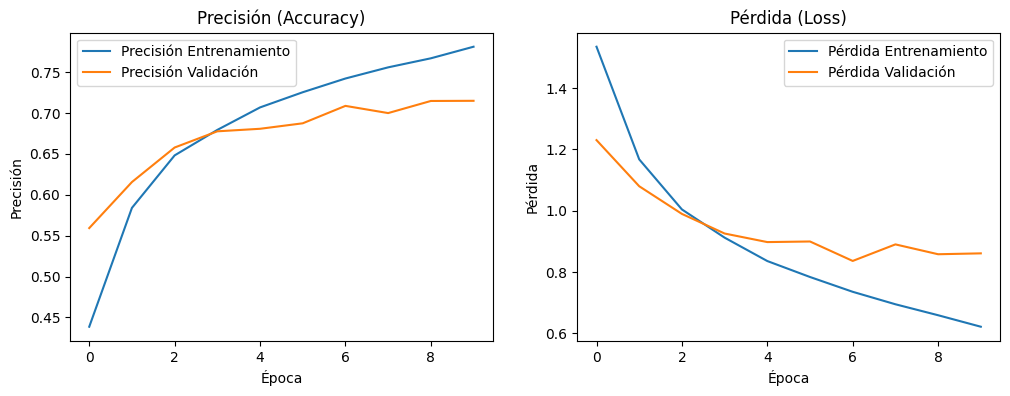

In [5]:
# 5. EVALUACIÓN DE RESULTADOS

# Graficamos la precisión y la pérdida durante el entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


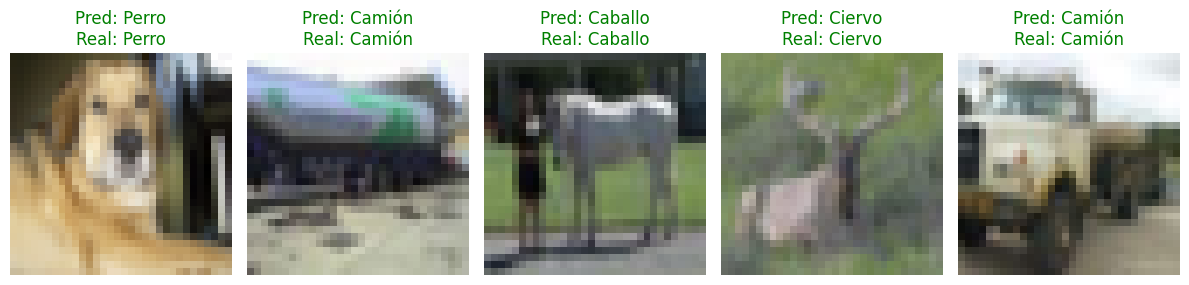

In [6]:
# 6. PREDICCIÓN EN IMÁGENES DE PRUEBA

# Convertimos las salidas del modelo en probabilidades mediante Softmax
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(x_test)

# Mostramos 5 predicciones aleatorias
plt.figure(figsize=(12, 3))
for i in range(5):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])

    pred_label = np.argmax(predictions[idx])
    true_label = y_test[idx][0]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {class_names[pred_label]}\nReal: {class_names[true_label]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()